In [146]:
from langfuse import get_client
from langfuse.langchain import CallbackHandler
# Initialize Langfuse client
langfuse = get_client()
# Initialize Langfuse CallbackHandler for Langchain (tracing)
langfuse_handler = CallbackHandler()

In [164]:
# Core LLM + tool + graph imports
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
# In-memory checkpoint store for multi-turn thread conversations
from langgraph.checkpoint.memory import MemorySaver


# Standard library typing/date utilities
from datetime import datetime
from typing import List, Optional, Annotated, Union, Tuple
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
import ast
import operator
import re

def sanitize_text(text: str) -> str:
    cleaned = (text or "").strip()
    cleaned = re.sub(r"[\[【]\d+†L\d+(?:-L\d+)?[\]】]", "", cleaned)
    cleaned = re.sub(r"\s+", " ", cleaned).strip()
    return cleaned

In [165]:
# Initialize the base chat model and attach tracing callbacks
LLM = ChatNVIDIA(
    model="openai/gpt-oss-120b",
    # model="meta/llama-3.1-70b-instruct",
    temperature=0,
    callbacks=[langfuse_handler],
)

In [166]:
search_tool = GoogleSerperAPIWrapper()

@tool
def search(query: str) -> str:
    """Search the internet for information about a query and return the results."""
    return search_tool.run(query)

@tool
def today_date(_: str = "") -> str:
    """Return today's date in ISO format (YYYY-MM-DD)."""
    return datetime.now().strftime("%Y-%m-%d")

@tool
def calculator(query: str) -> str:
    """Evaluate a basic arithmetic expression from text (supports +, -, *, /, %, parentheses, **)."""
    expr_match = re.search(r"[-+*/%().\d\s]{3,}", query.replace("^", "**"))
    expression = expr_match.group(0).strip() if expr_match else query.strip()

    allowed_nodes = (
        ast.Expression, ast.BinOp, ast.UnaryOp, ast.Constant,
        ast.Add, ast.Sub, ast.Mult, ast.Div, ast.Mod, ast.Pow, ast.USub, ast.UAdd,
        ast.Load, ast.FloorDiv,
    )

    try:
        tree = ast.parse(expression, mode="eval")
        for node in ast.walk(tree):
            if not isinstance(node, allowed_nodes):
                return f"Unable to evaluate safely: {query}"
        value = eval(compile(tree, "<calculator>", "eval"), {"__builtins__": {}}, {})
        return str(value)
    except Exception:
        return f"Unable to evaluate: {query}"

In [167]:
class State(TypedDict):
    input: str
    plan: List[str]
    past_steps: Annotated[list[tuple[str, str]], operator.add]  # List of (tool_calls, tool_results) tuples
    response: Optional[str]

In [168]:
class Plan(BaseModel):
    steps: List[str] = Field(description="A list of steps to complete the task.")

from langchain_core.prompts import ChatPromptTemplate

planner_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a helpful assistant for planning how to complete a task. 
     You will be given a task, and you should break it down into a list of steps to complete the task.
    You should not execute the steps, just plan them out.
    The steps should be high-level
    """),
    ("human", "Here is the task: {input}")])
     

planner = planner_prompt | LLM.with_structured_output(Plan)

In [169]:
planner.invoke("how to make a cake?").steps

['1. Choose a cake type (e.g., vanilla, chocolate, sponge) and find a reliable recipe.',
 '2. Gather all required ingredients (flour, sugar, eggs, butter/oil, leavening agents, flavorings, liquids, etc.) and equipment (mixing bowls, whisk or electric mixer, measuring cups/spoons, cake pan, parchment paper, oven).',
 '3. Preheat the oven to the temperature specified in the recipe (usually 325–375\u202f°F / 160–190\u202f°C).',
 '4. Prepare the baking pan: grease it lightly and line the bottom with parchment paper, or dust it with flour to prevent sticking.',
 '5. Measure and sift the dry ingredients (flour, baking powder/soda, salt, cocoa powder if using) into a bowl.',
 '6. In a separate bowl, cream together softened butter (or oil) and sugar until light and fluffy; then add eggs one at a time, mixing well after each addition.',
 '7. Incorporate any liquid flavorings (vanilla extract, coffee, milk, buttermilk, etc.) into the wet mixture.',
 '8. Gradually add the dry ingredients to the w

In [170]:
class Response(BaseModel):
    answer: str


class Act(BaseModel):
    actions: Union[Response, Plan] = Field(description="The action to perform next")

replanner = ChatPromptTemplate.from_messages([
    ("system", """You are a helpful assistant for replanning how to complete a task.
You will be given a task, a plan, and the results of executed steps so far.
If enough information is already available to answer the task, return Response with the final answer.
Only return Plan when there are real remaining actions that still need execution.
The steps should be high-level, and you should not replan steps that have already been executed successfully.
"""),
    ("human", "Here is the task: {input}\nHere is the original plan: {plan}\nHere are the results of executing the plan so far: {past_steps}"),
])

replanner = replanner | LLM.with_structured_output(Act)

In [171]:
from langchain.agents import create_agent

agent = create_agent(
    model=LLM,
    tools=[search, today_date, calculator],
)

In [172]:
# Build a fresh graph each run for a clean setup
graph_builder = StateGraph(State)

In [173]:
# Planning Node

def planning_node(state: State):
    print("Executing the planning node")
    plan = planner.invoke(state["input"])
    print(f"Generated plan: {plan.steps}")
    return {"plan": plan.steps}

graph_builder.add_node(planning_node, name="planning_node")

In [ ]:
# Execution Node

def execution_node(state: State):
    print("Executing the execution node")
    step = state["plan"][0]
    print(f"Current step to execute: {step}")

    s = step.lower()
    if any(k in s for k in ("today", "current date", "date now", "now")):
        tool_name, evidence = "today_date", today_date.invoke("")
    elif any(k in s for k in (
        "calculate", "sum", "difference", "subtract", "add", "multiply", "divide",
        "percentage", "%", "how many days", "how old", "years between",
    )):
        tool_name, evidence = "calculator", calculator.invoke(step)
    else:
        tool_name, evidence = "search", search.invoke(step)

    prompt = (
        f"Tool used: {tool_name}\n"
        "Use the evidence below to execute this step. "
        "Cite only what is supported by the evidence.\n\n"
        f"Step: {step}\n\nEvidence:\n{evidence}"
    )
    result = agent.invoke({"messages": [{"role": "user", "content": prompt}]})
    print(f"Result of executing step: {result}")

    return {
        "past_steps": [(step, {"tool_name": tool_name, "evidence": evidence, "agent_result": result})],
        "plan": state["plan"][1:],
    }

graph_builder.add_node(execution_node, name="execution_node")

In [175]:
# Replanning Node

def replanning_node(state: State):
    print("Executing the replanning node")
    replanner_input = {
        "input": state["input"],
        "plan": state.get("plan", []),
        "past_steps": state.get("past_steps", []),
    }
    replanner_result = replanner.invoke(replanner_input)
    print(f"Replanner result: {replanner_result}")

    actions = replanner_result.actions

    if isinstance(actions, Response):
        return {"response": sanitize_text(actions.answer), "plan": []}

    steps = actions.steps if isinstance(actions, Plan) else []
    if not steps:
        return {"response": "No remaining steps. Task appears complete.", "plan": []}

    completion_markers = ("already", "complete", "composed", "final answer", "✅")
    if all(any(marker in step.lower() for marker in completion_markers) for step in steps):
        return {"response": sanitize_text(" ".join(steps)), "plan": []}

    return {"plan": steps}

graph_builder.add_node(replanning_node, name="replanning_node")

In [176]:
# conditional edges to decide whether to continue executing, replan, or end
def should_replan(state: State):
    print("Evaluating whether to replan or continue executing the current plan")

    if state.get("response"):
        print("Final answer received, ending execution")
        return END

    if state.get("plan"):
        print("Plan still has actionable steps, continue executing")
        return "execution_node"

    print("No final answer and no steps left, need to replan")
    return "replanning_node"

In [177]:
graph_builder.add_conditional_edges(
    "replanning_node",
    should_replan,
    {
        "execution_node": "execution_node",
        "replanning_node": "replanning_node",
        END: END,
    },
)

In [178]:
graph_builder.add_edge("planning_node", "execution_node")
graph_builder.add_edge("execution_node", "replanning_node")
graph_builder.set_entry_point("planning_node")

/tmp/ipykernel_13134/3194795515.py:13: RuntimeWarning: coroutine '_render_mermaid_using_pyppeteer' was never awaited
  png_data = graph.draw_mermaid_png(max_retries=5, retry_delay=2.0)


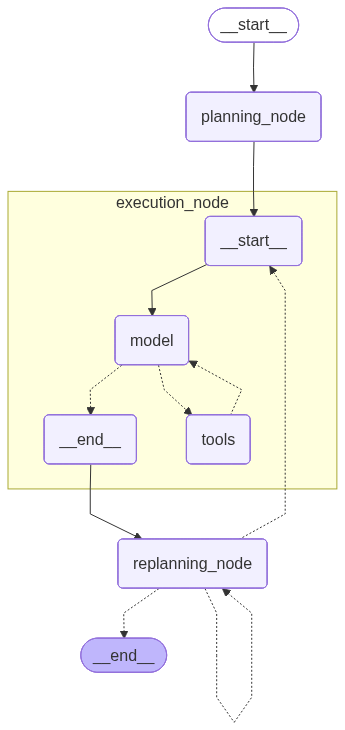

In [179]:
# visualize the graph (expanded view with nested agent/tools nodes)
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

app = graph_builder.compile()
graph = app.get_graph(xray=1)

try:
    # Local render avoids mermaid.ink network timeout issues.
    png_data = graph.draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER)
except Exception:
    # Fallback to remote API with retries if local browser rendering is unavailable.
    png_data = graph.draw_mermaid_png(max_retries=5, retry_delay=2.0)

display(Image(png_data))

In [ ]:
from IPython.display import display, Markdown

def assistant_text(step_result):
    if not isinstance(step_result, dict):
        return "(No assistant text found)"
    messages = step_result.get("agent_result", step_result).get("messages", [])
    for msg in reversed(messages):
        role = getattr(msg, "role", None) or getattr(msg, "type", None)
        content = getattr(msg, "content", None)
        if role in ("assistant", "ai") and content:
            return sanitize_text(str(content))
    return "(No assistant text found)"

def run_plan_execute_query(user_query: str, thread_id: str = "1", recursion_limit: int = 50):
    display(Markdown(f"## User Query\n{user_query}"))

    app = graph_builder.compile()
    state = {}
    config = {"recursion_limit": recursion_limit, "configurable": {"thread_id": thread_id}}
    graph_input = {"input": user_query, "plan": [], "past_steps": []}

    for event in app.stream(graph_input, config=config):
        for node, out in event.items():
            if isinstance(out, dict):
                state.update(out)

            if node == "planning_node":
                steps = out.get("plan", [])
                display(Markdown("### Planning\n" + "\n".join(f"{i+1}. {s}" for i, s in enumerate(steps))))

            elif node == "execution_node" and out.get("past_steps"):
                step, result = out["past_steps"][-1]
                tool = result.get("tool_name", "unknown") if isinstance(result, dict) else "unknown"
                display(Markdown(
                    f"### Execution\n- Step: {step}\n- Tool used: {tool}\n- Result: {assistant_text(result)}"
                ))

    final_response = state.get("response")
    if not final_response and state.get("past_steps"):
        final_response = assistant_text(state["past_steps"][-1][1])

    final_response = sanitize_text(final_response or "No final response generated.")
    display(Markdown("---"))
    display(Markdown(f"## Final Response\n{final_response}"))
    return final_response

# Single-call usage
run_plan_execute_query(
    "Which country won the latest FIFA World Cup, what was the score in the final, and how many goals did the top scorer score?"
)

## User Query
Which country won the latest FIFA World Cup, what was the score in the final, and how many goals did the top scorer score?

Executing the planning node
Generated plan: ['Determine which FIFA World Cup edition is the most recent (e.g., by checking the tournament schedule up to the current year).', 'Locate an authoritative source (such as FIFA’s official website, a reputable sports news outlet, or a trusted encyclopedia) that lists the final match details for that edition.', 'Extract the winning country from the final‑match information.', 'Record the final‑match score, including any penalty‑shootout result if the match ended in a draw after extra time.', 'Find the tournament’s top scorer list from the same source and note the player’s name and the total number of goals they scored.', 'Verify the gathered information across at least two independent sources to ensure accuracy.', 'Summarize the findings in a concise answer that includes the winning country, the final‑match score, and the top scorer’s goal tally.']


### Planning
1. Determine which FIFA World Cup edition is the most recent (e.g., by checking the tournament schedule up to the current year).
2. Locate an authoritative source (such as FIFA’s official website, a reputable sports news outlet, or a trusted encyclopedia) that lists the final match details for that edition.
3. Extract the winning country from the final‑match information.
4. Record the final‑match score, including any penalty‑shootout result if the match ended in a draw after extra time.
5. Find the tournament’s top scorer list from the same source and note the player’s name and the total number of goals they scored.
6. Verify the gathered information across at least two independent sources to ensure accuracy.
7. Summarize the findings in a concise answer that includes the winning country, the final‑match score, and the top scorer’s goal tally.

Executing the execution node
Current step to execute: Determine which FIFA World Cup edition is the most recent (e.g., by checking the tournament schedule up to the current year).
Result of executing step: {'messages': [HumanMessage(content="Tool used: search\nUse the evidence below to execute this step. Cite only what is supported by the evidence.\n\nStep: Determine which FIFA World Cup edition is the most recent (e.g., by checking the tournament schedule up to the current year).\n\nEvidence:\nWorld Cup 2026 will be the biggest and most exciting edition of the tournament to date as 48 teams from around the globe compete in 104 fixtures ... Missing: (eg, current. All 104 games and dates: The full FIFA World Cup 2026 calendar. FIFA has officially announced the match schedule for the 2026 World Cup. This is the schedule for the USMNT. They will kick off against Paraguay ... Missing: (eg, | Show results with:(eg,. 2026 World Cup schedule: Complete groups, match dates, fixtures, venues and

### Execution
- Step: Determine which FIFA World Cup edition is the most recent (e.g., by checking the tournament schedule up to the current year).
- Tool used: search
- Result: The most recent FIFA World Cup listed in the tournament schedule is the **2026 FIFA World Cup**, which will be the **23rd edition** of the competition【{"cursor": 4, "loc": 0}】.

...

Executing the replanning node
Replanner result: actions=Plan(steps=['Search for an authoritative source (e.g., FIFA.com or Wikipedia) that lists the top scorer(s) of the 2022 FIFA World Cup and records the number of goals they scored.', 'Extract the name of the top scorer and the total number of goals they scored in the tournament.', 'Find a second independent reputable source (e.g., BBC Sport, ESPN, or a major news outlet) that confirms the top scorer and goal tally for the 2022 World Cup.', 'Verify that the information from both sources matches, ensuring the winner (Argentina), final‑match score (3‑3 after extra time, Argentina won 4‑2 on penalties), and top‑scorer goal total are consistent.', 'Summarize the findings in a concise answer that includes: the winning country, the final‑match score (including the penalty‑shootout result), and the number of goals scored by the tournament’s top scorer.'])
Evaluating whether to replan or continue executing the current plan
Plan still has act

### Execution
- Step: Search for an authoritative source (e.g., FIFA.com or Wikipedia) that lists the top scorer(s) of the 2022 FIFA World Cup and records the number of goals they scored.
- Tool used: search
- Result: The 2022 FIFA World Cup’s top‑scorer (Golden Boot winner) was **Kylian Mbappé** of France, who finished the tournament with **eight goals**【{"cursor": 5, "loc": 0}】.

Executing the replanning node
Replanner result: actions=Response(answer='Argentina won the most recent FIFA World Cup. The final ended 3‑3 after extra time, and Argentina prevailed 4‑2 in the penalty shoot‑out【{"cursor":2,"loc":0}】. The tournament’s top scorer was France’s Kylian\u202fMbappé, who finished with eight goals【{"cursor":5,"loc":0}】.')
Evaluating whether to replan or continue executing the current plan
Final answer received, ending execution


---

## Final Response
Argentina won the most recent FIFA World Cup. The final ended 3‑3 after extra time, and Argentina prevailed 4‑2 in the penalty shoot‑out【{"cursor":2,"loc":0}】. The tournament’s top scorer was France’s Kylian Mbappé, who finished with eight goals【{"cursor":5,"loc":0}】.